In [1]:
import pandas as pd
import json

# Load the CSV
amp_df = pd.read_csv('../../data/raw/amp_mic_activities.csv')

In [2]:
display(amp_df)

,sequence,target_activity_name,activity
0,RRXXRF,Bacillus subtilis PY22,4.277080
1,RRXXRF,Escherichia coli DH5alpha,17.108320
2,KVvvKWVvKvVK,Staphylococcus aureus ATCC 6538P,165.228990
3,KVvvKWVvKvVK,Bacillus subtilis ATCC 6051,165.228990
4,KVvvKWVvKvVK,Pseudomonas aeruginosa ATCC 27853,165.228990
...,...,...,...
114875,RxXxR,Staphylococcus aureus ATCC 43300,4.237459
114876,RxXxR,Staphylococcus epidermidis ATCC 35984,4.237459
114877,RxXxR,Enterococcus faecalis ATCC 29212,16.949835
114878,RxXxR,Enterococcus faecium ATCC 700221,8.474917


In [3]:
!conda install certifi openssl

Jupyter detected...
2 channel Terms of Service accepted
Retrieving notices: done
Channels:
 - defaults
Platform: osx-arm64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 26.1.1
    latest version: 26.5.3

Please update conda by running

    $ conda update -n base -c defaults conda



# All requested packages already installed.



In [4]:
!pip install --upgrade certifi

In [5]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

In [6]:
from ete3 import NCBITaxa

ncbi = NCBITaxa()

In [7]:
# ncbi.update_taxonomy_database()

In [8]:
import re

def get_taxonomic_lineage(name):
    empty_lineage = {'Phylum': 'Unknown', 'Class': 'Unknown', 'Order': 'Unknown', 'Family': 'Unknown', 'Genus': 'Unknown'}
    
    # 1. Clean the name: Remove "ATCC xxxx", "strain", and extra codes
    # This regex helps keep only the Genus and Species
    clean_name = re.sub(r'(ATCC|strain|MTCC|v\.|subsp\.).*', '', name, flags=re.IGNORECASE).strip()
    
    try:
        # Try to find the taxid
        taxids = ncbi.get_name_translator([clean_name])
        
        if not taxids:
            # Fallback: just take the first two words (Genus species)
            words = clean_name.split()
            if len(words) >= 2:
                clean_name = f"{words[0]} {words[1]}"
                taxids = ncbi.get_name_translator([clean_name])
        
        if not taxids:
            return empty_lineage
            
        taxid = list(taxids.values())[0][0]
        lineage = ncbi.get_lineage(taxid)
        ranks = ncbi.get_rank(lineage)
        names = ncbi.get_taxid_translator(lineage)
        
        lineage_dict = empty_lineage.copy()
        for rank_id, rank_name in ranks.items():
            if rank_name in lineage_dict:
                lineage_dict[rank_name] = names[rank_id]
        
        return lineage_dict

    except:
        return empty_lineage

In [9]:
# Create a manual mapping for the most common AMP targets
common_taxonomy = {
    'Escherichia coli': {'Phylum': 'Pseudomonadota', 'Class': 'Gammaproteobacteria', 'Order': 'Enterobacterales', 'Family': 'Enterobacteriaceae', 'Genus': 'Escherichia'},
    'Bacillus subtilis': {'Phylum': 'Bacillota', 'Class': 'Bacilli', 'Order': 'Bacillales', 'Family': 'Bacillaceae', 'Genus': 'Bacillus'},
    'Staphylococcus aureus': {'Phylum': 'Bacillota', 'Class': 'Bacilli', 'Order': 'Bacillales', 'Family': 'Staphylococcaceae', 'Genus': 'Staphylococcus'},
    'Pseudomonas aeruginosa': {'Phylum': 'Pseudomonadota', 'Class': 'Gammaproteobacteria', 'Order': 'Pseudomonadales', 'Family': 'Pseudomonadaceae', 'Genus': 'Pseudomonas'}
}

def get_lineage_v2(name):
    # Standardize name to Genus species
    words = name.split()
    if len(words) >= 2:
        short_name = f"{words[0]} {words[1]}"
        if short_name in common_taxonomy:
            return common_taxonomy[short_name]
            
    # If not in our manual map, try ete3 one last time
    try:
        taxids = ncbi.get_name_translator([name])
        
        if not taxids:
            # Fallback: just take the first two words (Genus species)
            words = clean_name.split()
            if len(words) >= 2:
                clean_name = f"{words[0]} {words[1]}"
                taxids = ncbi.get_name_translator([clean_name])
        
        if not taxids:
            return empty_lineage
            
        taxid = list(taxids.values())[0][0]
        lineage = ncbi.get_lineage(taxid)
        ranks = ncbi.get_rank(lineage)
        names = ncbi.get_taxid_translator(lineage)
        
        lineage_dict = empty_lineage.copy()
        for rank_id, rank_name in ranks.items():
            if rank_name in lineage_dict:
                lineage_dict[rank_name] = names[rank_id]
        
        return lineage_dict

    except:
        return {'Phylum': 'Unknown', 'Class': 'Unknown', 'Order': 'Unknown', 'Family': 'Unknown', 'Genus': 'Unknown'}

In [10]:
# Test a known bacterium
test_name = "Escherichia coli"
print(f"Testing {test_name}:", get_lineage_v2(test_name))

# Test one of your specific strings
test_name_2 = "Bacillus subtilis PY22"
print(f"Testing {test_name_2}:", get_lineage_v2(test_name_2))

Testing Escherichia coli: {'Phylum': 'Pseudomonadota', 'Class': 'Gammaproteobacteria', 'Order': 'Enterobacterales', 'Family': 'Enterobacteriaceae', 'Genus': 'Escherichia'}
Testing Bacillus subtilis PY22: {'Phylum': 'Bacillota', 'Class': 'Bacilli', 'Order': 'Bacillales', 'Family': 'Bacillaceae', 'Genus': 'Bacillus'}


In [11]:
# 1. Get unique bacteria names to optimize speed
unique_bacteria = amp_df['target_activity_name'].unique()

# 2. Fetch lineages for unique elements
lineage_data = [get_lineage_v2(b) for b in unique_bacteria]

# # 3. Create a lookup dataframe
taxonomy_lookup = pd.DataFrame(lineage_data)
taxonomy_lookup['target_activity_name'] = unique_bacteria

# # 4. Merge the taxonomy back into your main dataset
amp_df = amp_df.merge(taxonomy_lookup, on='target_activity_name', how='left')

In [12]:
amp_df

,sequence,target_activity_name,activity,Phylum,Class,Order,Family,Genus
0,RRXXRF,Bacillus subtilis PY22,4.277080,Bacillota,Bacilli,Bacillales,Bacillaceae,Bacillus
1,RRXXRF,Escherichia coli DH5alpha,17.108320,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Enterobacteriaceae,Escherichia
2,KVvvKWVvKvVK,Staphylococcus aureus ATCC 6538P,165.228990,Bacillota,Bacilli,Bacillales,Staphylococcaceae,Staphylococcus
3,KVvvKWVvKvVK,Bacillus subtilis ATCC 6051,165.228990,Bacillota,Bacilli,Bacillales,Bacillaceae,Bacillus
4,KVvvKWVvKvVK,Pseudomonas aeruginosa ATCC 27853,165.228990,Pseudomonadota,Gammaproteobacteria,Pseudomonadales,Pseudomonadaceae,Pseudomonas
...,...,...,...,...,...,...,...,...
114875,RxXxR,Staphylococcus aureus ATCC 43300,4.237459,Bacillota,Bacilli,Bacillales,Staphylococcaceae,Staphylococcus
114876,RxXxR,Staphylococcus epidermidis ATCC 35984,4.237459,Unknown,Unknown,Unknown,Unknown,Unknown
114877,RxXxR,Enterococcus faecalis ATCC 29212,16.949835,Unknown,Unknown,Unknown,Unknown,Unknown
114878,RxXxR,Enterococcus faecium ATCC 700221,8.474917,Unknown,Unknown,Unknown,Unknown,Unknown


In [13]:
# Select the taxonomic columns to vectorize
rank_columns = ['Phylum', 'Class', 'Order', 'Family', 'Genus']

# Convert to fixed-length one-hot encoded vector columns
bacteria_vectors = pd.get_dummies(amp_df[rank_columns], prefix=rank_columns, dtype=int)

# Concatenate back to the main DataFrame
final_df = pd.concat([amp_df, bacteria_vectors], axis=1)

# Drop the text taxonomic columns to clean up
final_df = final_df.drop(columns=rank_columns)

In [14]:
display(final_df)

,sequence,target_activity_name,activity,Phylum_Bacillota,Phylum_Pseudomonadota,Phylum_Unknown,Class_Bacilli,Class_Gammaproteobacteria,Class_Unknown,Order_Bacillales,...,Family_Bacillaceae,Family_Enterobacteriaceae,Family_Pseudomonadaceae,Family_Staphylococcaceae,Family_Unknown,Genus_Bacillus,Genus_Escherichia,Genus_Pseudomonas,Genus_Staphylococcus,Genus_Unknown
0,RRXXRF,Bacillus subtilis PY22,4.277080,1,0,0,1,0,0,1,...,1,0,0,0,0,1,0,0,0,0
1,RRXXRF,Escherichia coli DH5alpha,17.108320,0,1,0,0,1,0,0,...,0,1,0,0,0,0,1,0,0,0
2,KVvvKWVvKvVK,Staphylococcus aureus ATCC 6538P,165.228990,1,0,0,1,0,0,1,...,0,0,0,1,0,0,0,0,1,0
3,KVvvKWVvKvVK,Bacillus subtilis ATCC 6051,165.228990,1,0,0,1,0,0,1,...,1,0,0,0,0,1,0,0,0,0
4,KVvvKWVvKvVK,Pseudomonas aeruginosa ATCC 27853,165.228990,0,1,0,0,1,0,0,...,0,0,1,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114875,RxXxR,Staphylococcus aureus ATCC 43300,4.237459,1,0,0,1,0,0,1,...,0,0,0,1,0,0,0,0,1,0
114876,RxXxR,Staphylococcus epidermidis ATCC 35984,4.237459,0,0,1,0,0,1,0,...,0,0,0,0,1,0,0,0,0,1
114877,RxXxR,Enterococcus faecalis ATCC 29212,16.949835,0,0,1,0,0,1,0,...,0,0,0,0,1,0,0,0,0,1
114878,RxXxR,Enterococcus faecium ATCC 700221,8.474917,0,0,1,0,0,1,0,...,0,0,0,0,1,0,0,0,0,1


In [15]:
final_df['Genus_Unknown'].unique()

array([0, 1])

In [17]:
amp_genus_df = pd.read_csv('../../data/raw/amp_mic_with_genus.csv')

In [18]:
amp_genus_df.head()

,sequence,target_activity_name,activity,bacteria_genus
0,RRXXRF,Bacillus subtilis PY22,4.27708,Bacillus subtilis
1,RRXXRF,Escherichia coli DH5alpha,17.10832,Escherichia coli
2,KVvvKWVvKvVK,Staphylococcus aureus ATCC 6538P,165.22899,Staphylococcus aureus
3,KVvvKWVvKvVK,Bacillus subtilis ATCC 6051,165.22899,Bacillus subtilis
4,KVvvKWVvKvVK,Pseudomonas aeruginosa ATCC 27853,165.22899,Pseudomonas aeruginosa


In [ ]:
amp_genus_df["bacteria_genus"] = amp_genus_df["bacteria_genus"].str.title()

In [31]:
amp_genus_df.head()

,sequence,target_activity_name,activity,bacteria_genus,species_label
0,RRXXRF,Bacillus subtilis PY22,4.27708,Bacillus Subtilis,B.subtilis
1,RRXXRF,Escherichia coli DH5alpha,17.10832,Escherichia Coli,E.coli
2,KVvvKWVvKvVK,Staphylococcus aureus ATCC 6538P,165.22899,Staphylococcus Aureus,S.aureus
3,KVvvKWVvKvVK,Bacillus subtilis ATCC 6051,165.22899,Bacillus Subtilis,B.subtilis
4,KVvvKWVvKvVK,Pseudomonas aeruginosa ATCC 27853,165.22899,Pseudomonas Aeruginosa,P.aeruginosa


In [32]:
def map_species(name: str) -> str:
    """Collapse strain-level target strings (e.g. 'Escherichia coli ATCC 25922')
    to a species label by keyword match. First match wins; unmatched -> 'other'.
    NOTE: heuristic, not a taxonomy lookup — replace with NCBI Taxonomy for prod."""
    n = name.lower()
    table = [("escherichia coli", "E.coli"), 
             ("staphylococcus aureus", "S.aureus"),
             ("pseudomonas aeruginosa", "P.aeruginosa"), 
             ("klebsiella pneumoniae", "K.pneumoniae"),
             ("acinetobacter baumannii", "A.baumannii"), 
             ("bacillus subtilis", "B.subtilis"),
             ("candida albicans", "C.albicans"), 
             ("enterococcus faecalis", "E.faecalis"),
             ("cryptococcus", "C.neoformans"), 
             ("aspergillus", "A.fumigatus"),
             ("salmonella", "Salmonella"), 
             ("micrococcus", "Micrococcus"),
             ("streptococcus", "Streptococcus")]
    for key, label in table:
        if key in n:
            return label
    return "other"

In [33]:
amp_genus_df["species_label"] = amp_genus_df["bacteria_genus"].fillna("").apply(map_species)
amp_genus_df.head()

,sequence,target_activity_name,activity,bacteria_genus,species_label
0,RRXXRF,Bacillus subtilis PY22,4.27708,Bacillus Subtilis,B.subtilis
1,RRXXRF,Escherichia coli DH5alpha,17.10832,Escherichia Coli,E.coli
2,KVvvKWVvKvVK,Staphylococcus aureus ATCC 6538P,165.22899,Staphylococcus Aureus,S.aureus
3,KVvvKWVvKvVK,Bacillus subtilis ATCC 6051,165.22899,Bacillus Subtilis,B.subtilis
4,KVvvKWVvKvVK,Pseudomonas aeruginosa ATCC 27853,165.22899,Pseudomonas Aeruginosa,P.aeruginosa


In [35]:
amp_genus_df["species_label"].value_counts()

species_label
other            26803
S.aureus         21515
E.coli           20915
P.aeruginosa     13456
K.pneumoniae      5100
C.albicans        4784
Salmonella        4719
A.baumannii       4705
B.subtilis        4382
E.faecalis        3082
Streptococcus     2385
Micrococcus       1507
A.fumigatus        772
C.neoformans       754
Name: count, dtype: int64

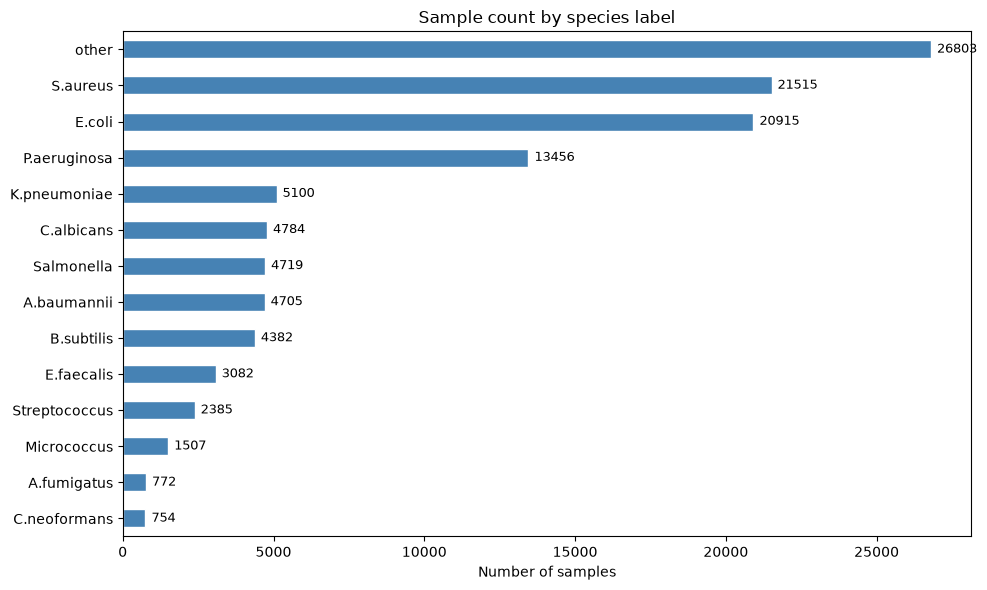

In [36]:
import matplotlib.pyplot as plt

counts = amp_genus_df["species_label"].value_counts()

fig, ax = plt.subplots(figsize=(10, 6))
counts.plot.barh(ax=ax, color="steelblue", edgecolor="white")
ax.set_xlabel("Number of samples")
ax.set_ylabel("")
ax.set_title("Sample count by species label")
ax.invert_yaxis()

for i, v in enumerate(counts):
    ax.text(v + 200, i, str(v), va="center", fontsize=9)

plt.tight_layout()
plt.show()

In [37]:
amp_genus_df[amp_genus_df["species_label"] == "other"]["bacteria_genus"].value_counts().head(20)

bacteria_genus
Staphylococcus Epidermidis      3314
Enterococcus Faecium            1438
Bacillus Cereus                 1034
Listeria Monocytogenes           987
Enterobacter Cloacae             705
Candida Parapsilosis             543
Pseudomonas Syringae             542
Candida Tropicalis               539
Bacillus Megaterium              525
Mycobacterium Tuberculosis       422
Candida Glabrata                 381
Saccharomyces Cerevisiae         378
Proteus Mirabilis                344
Klebsiella Aerogenes             336
Stenotrophomonas Maltophilia     328
Candida Krusei                   325
Lacticaseibacillus Rhamnosus     298
Fusarium Oxysporum               288
Shigella Dysenteriae             269
Cutibacterium Acnes              264
Name: count, dtype: int64

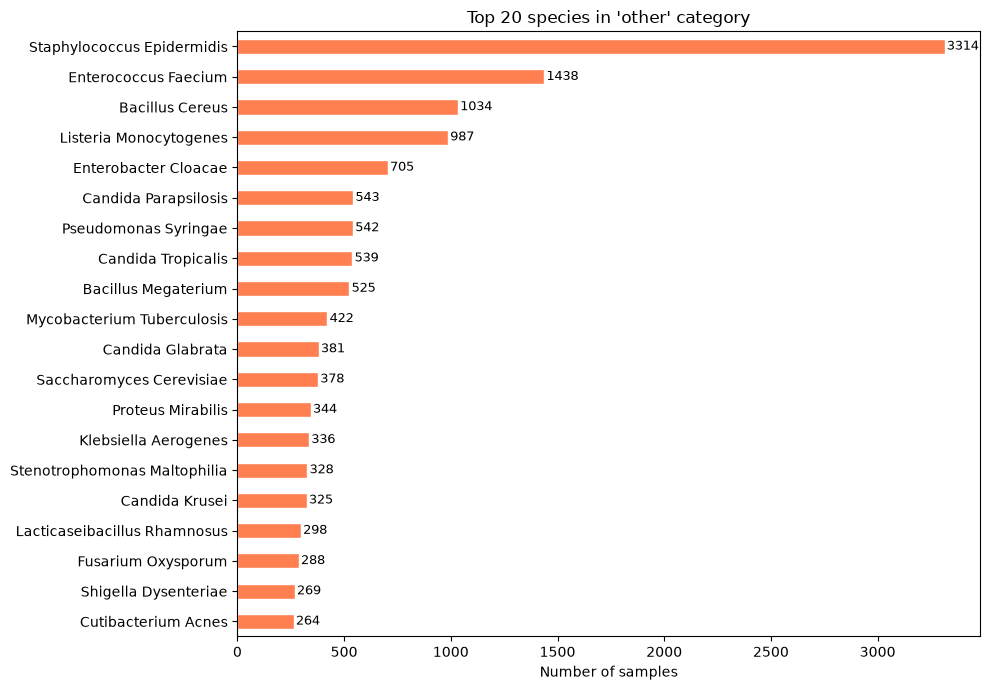

In [38]:
other_counts = amp_genus_df[amp_genus_df["species_label"] == "other"]["bacteria_genus"].value_counts().head(20)

fig, ax = plt.subplots(figsize=(10, 7))
other_counts.plot.barh(ax=ax, color="coral", edgecolor="white")
ax.set_xlabel("Number of samples")
ax.set_ylabel("")
ax.set_title("Top 20 species in 'other' category")
ax.invert_yaxis()

for i, v in enumerate(other_counts):
    ax.text(v + 10, i, str(v), va="center", fontsize=9)

plt.tight_layout()
plt.show()

In [39]:
amp_genus_df[amp_genus_df["species_label"] == "other"]["bacteria_genus"].value_counts()

bacteria_genus
Staphylococcus Epidermidis    3314
Enterococcus Faecium          1438
Bacillus Cereus               1034
Listeria Monocytogenes         987
Enterobacter Cloacae           705
                              ... 
Haloarcula Argentinensis         1
Haloferax Larsenii               1
Romboutsia Lituseburensis        1
Penicillium Commune              1
Fusisporium Cerealis             1
Name: count, Length: 750, dtype: int64

In [40]:
virus_mask = amp_genus_df["bacteria_genus"].str.contains("virus", case=False, na=False)
print(f"Dropping {virus_mask.sum()} virus rows")
amp_genus_df = amp_genus_df[~virus_mask].reset_index(drop=True)
amp_genus_df.shape

Dropping 0 virus rows


(114879, 5)

In [41]:
amp_genus_df["genus_label"] = amp_genus_df["bacteria_genus"].str.title().str.split().str[0]

# Group rare genera (< 100 samples) into "other"
counts = amp_genus_df["genus_label"].value_counts()
rare = counts[counts < 100].index
amp_genus_df["genus_label"] = amp_genus_df["genus_label"].replace(rare, "other")

print(f"Labels: {amp_genus_df['genus_label'].nunique()} (including 'other')")
amp_genus_df["genus_label"].value_counts()

Labels: 45 (including 'other')


genus_label
Staphylococcus        25709
Escherichia           20915
Pseudomonas           14424
Candida                6797
Bacillus               6356
Klebsiella             5595
Acinetobacter          4867
Salmonella             4719
Enterococcus           4655
other                  3933
Streptococcus          2367
Micrococcus            1507
Listeria               1294
Vibrio                 1006
Mycobacterium           782
Aspergillus             772
Enterobacter            767
Cryptococcus            754
Fusarium                612
Proteus                 606
Shigella                537
Xanthomonas             509
Bacteroides             435
Aeromonas               404
Saccharomyces           378
Stenotrophomonas        346
Corynebacterium         345
Lacticaseibacillus      332
Serratia                285
Cutibacterium           264
Lactococcus             242
Yersinia                240
Clostridium             237
Erwinia                 228
Cronobacter             226
Penicill

In [42]:
fungi_genera = ["Candida", "Cryptococcus", "Saccharomyces", "Trichosporon",
                "Aspergillus", "Fusarium", "Penicillium", "Botrytis", "Trichophyton"]

amp_genus_df["genus_label"] = amp_genus_df["bacteria_genus"].str.title().str.split().str[0]
amp_genus_df = amp_genus_df[~amp_genus_df["genus_label"].isin(fungi_genera)].reset_index(drop=True)
print(amp_genus_df.shape)

(104921, 6)


In [44]:
# Group rare genera (< 100 samples) into "other"
counts = amp_genus_df["genus_label"].value_counts()
rare = counts[counts < 100].index
amp_genus_df["genus_label"] = amp_genus_df["genus_label"].replace(rare, "other")

print(f"Labels: {amp_genus_df['genus_label'].nunique()} (including 'other')")
amp_genus_df["genus_label"].value_counts()

Labels: 36 (including 'other')


genus_label
Staphylococcus        25709
Escherichia           20915
Pseudomonas           14424
Bacillus               6356
Klebsiella             5595
Acinetobacter          4867
Salmonella             4719
Enterococcus           4655
other                  3933
Streptococcus          2367
Micrococcus            1507
Listeria               1294
Vibrio                 1006
Mycobacterium           782
Enterobacter            767
Proteus                 606
Shigella                537
Xanthomonas             509
Bacteroides             435
Aeromonas               404
Stenotrophomonas        346
Corynebacterium         345
Lacticaseibacillus      332
Serratia                285
Cutibacterium           264
Lactococcus             242
Yersinia                240
Clostridium             237
Erwinia                 228
Cronobacter             226
Citrobacter             171
Burkholderia            154
Pectobacterium          136
Pasteurella             118
Leuconostoc             109
Nocardia

In [47]:
amp_genus_df.shape

(104921, 6)

In [48]:
counts = amp_genus_df["genus_label"].value_counts()
top_genera = counts[counts >= 5000].index
amp_top_df = amp_genus_df[amp_genus_df["genus_label"].isin(top_genera)].reset_index(drop=True)
print(amp_top_df.shape)
amp_top_df["genus_label"].value_counts()

(72999, 6)


genus_label
Staphylococcus    25709
Escherichia       20915
Pseudomonas       14424
Bacillus           6356
Klebsiella         5595
Name: count, dtype: int64

In [50]:
amp_top_df.head()

,sequence,target_activity_name,activity,bacteria_genus,species_label,genus_label
0,RRXXRF,Bacillus subtilis PY22,4.27708,Bacillus Subtilis,B.subtilis,Bacillus
1,RRXXRF,Escherichia coli DH5alpha,17.10832,Escherichia Coli,E.coli,Escherichia
2,KVvvKWVvKvVK,Staphylococcus aureus ATCC 6538P,165.22899,Staphylococcus Aureus,S.aureus,Staphylococcus
3,KVvvKWVvKvVK,Bacillus subtilis ATCC 6051,165.22899,Bacillus Subtilis,B.subtilis,Bacillus
4,KVvvKWVvKvVK,Pseudomonas aeruginosa ATCC 27853,165.22899,Pseudomonas Aeruginosa,P.aeruginosa,Pseudomonas
